# Tiny Shakespeare Text Generation — LSTM CPU/GPU Benchmark
## Standalone, switchable-device notebook

This notebook benchmarks **only LSTM** for character-level text generation.

Change only:
```python
DEVICE = "cpu"
```
or:
```python
DEVICE = "cuda"
```

The notebook uses the **entire Tiny Shakespeare text with no sampling/subsampling**. The full text is split deterministically into 90% training, 5% validation, and 5% test. Every available next-character pair inside each split is used.

Both CPU and GPU runs keep the same dataset, split, vocabulary, sequence length, batch size, epochs, learning rate, model dimensions, optimizer, initial weights, batch order, evaluation, and generation settings.


## 1. Install CodeCarbon

In [1]:

import subprocess
import sys
import importlib.util

def ensure_package(module_name, package_name=None):
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name or module_name,
        ])

ensure_package("codecarbon")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.9/396.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 105.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
sigstore 4.3.0 requires cryptography<49,>=42, but you have cryptography 50.0.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 50.0.0 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 50.0.0 which is incompatible.


## 2. Imports and environment

In [2]:

import os
import gc
import copy
import glob
import math
import time
import random
import zipfile
import platform
import threading
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from codecarbon import EmissionsTracker

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Logical CPU cores:", os.cpu_count())
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)


Python: 3.12.13
PyTorch: 2.10.0+cu128
Logical CPU cores: 4
CUDA available: True
GPU: Tesla T4
CUDA: 12.8



## 3. Choose CPU or GPU

### Change only this line between the two benchmark runs

For CPU:

```python
DEVICE = "cpu"
```

For GPU:

```python
DEVICE = "cuda"
```


In [3]:

# ============================================================
# CHANGE ONLY THIS LINE BETWEEN CPU AND GPU EXPERIMENTS
# ============================================================
DEVICE = "cuda"          # "cpu" or "cuda"
# ============================================================

DEVICE = DEVICE.lower().strip()

if DEVICE not in {"cpu", "cuda"}:
    raise ValueError('DEVICE must be either "cpu" or "cuda".')

if DEVICE == "cuda" and not torch.cuda.is_available():
    raise RuntimeError(
        "DEVICE='cuda' was selected but CUDA is unavailable. "
        "On Kaggle, enable Accelerator = GPU."
    )

print("Selected device:", DEVICE.upper())


Selected device: CUDA


## 4. Fixed experimental configuration

In [4]:
SEED = 42

TRAIN_FRACTION = 0.90
VAL_FRACTION = 0.05
TEST_FRACTION = 0.05

SEQ_LEN = 128
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 1e-3
EMBED_DIM = 256
HIDDEN_DIM = 384
NUM_LAYERS = 2
DROPOUT = 0.1
GRAD_CLIP = 1.0
GEN_LEN = 500
GEN_TEMPERATURE = 0.8
GEN_REPEATS = 3
CARBON_MEASURE_SECS = 1
IGNORE_INDEX = -100
LN2 = math.log(2.0)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

set_seed(SEED)

print({
    "device": DEVICE,
    "sequence_length": SEQ_LEN,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "embedding_dim": EMBED_DIM,
    "hidden_dim": HIDDEN_DIM,
    "layers": NUM_LAYERS,
})


{'device': 'cuda', 'sequence_length': 128, 'batch_size': 64, 'epochs': 5, 'learning_rate': 0.001, 'embedding_dim': 256, 'hidden_dim': 384, 'layers': 2}


## 5. Load full Tiny Shakespeare

The notebook uses the complete Tiny Shakespeare text. It first searches Kaggle/local files and otherwise downloads Karpathy's standard `tinyshakespeare/input.txt`. No subset is selected after loading.


In [5]:
TINY_SHAKESPEARE_URL = (
    "https://raw.githubusercontent.com/karpathy/"
    "char-rnn/master/data/tinyshakespeare/input.txt"
)

def find_local_tiny_shakespeare():
    patterns = [
        "/kaggle/input/**/*shakespeare*.txt",
        "/kaggle/input/**/input.txt",
        "./data/**/*shakespeare*.txt",
        "./data/**/input.txt",
    ]
    for pattern in patterns:
        for path in glob.glob(pattern, recursive=True):
            try:
                if not os.path.isfile(path):
                    continue
                size = os.path.getsize(path)
                if 900_000 <= size <= 2_000_000:
                    txt = Path(path).read_text(encoding="utf-8")
                    if "First Citizen:" in txt and "ROMEO" in txt:
                        return path
            except Exception:
                pass
    return None

def load_tiny_shakespeare():
    local_path = find_local_tiny_shakespeare()
    if local_path is not None:
        print("Using local Tiny Shakespeare:", local_path)
        return Path(local_path).read_text(encoding="utf-8")

    data_dir = Path("data")
    data_dir.mkdir(parents=True, exist_ok=True)
    target = data_dir / "tiny_shakespeare.txt"
    try:
        print("Downloading full Tiny Shakespeare...")
        urllib.request.urlretrieve(TINY_SHAKESPEARE_URL, target)
        return target.read_text(encoding="utf-8")
    except Exception as exc:
        raise RuntimeError(
            "Tiny Shakespeare was not found locally and could not be downloaded. "
            "On Kaggle, add a Tiny Shakespeare dataset or enable Internet."
        ) from exc

text = load_tiny_shakespeare()
total_chars = len(text)
train_end = int(total_chars * TRAIN_FRACTION)
val_end = train_end + int(total_chars * VAL_FRACTION)

train_text = text[:train_end]
val_text = text[train_end:val_end]
test_text = text[val_end:]

vocab = sorted(set(text))
VOCAB_SIZE = len(vocab)
stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s):
    return torch.tensor([stoi[ch] for ch in s], dtype=torch.long)

def decode(ids):
    return "".join(itos[int(i)] for i in ids)

train_ids = encode(train_text)
val_ids = encode(val_text)
test_ids = encode(test_text)

print("Total characters:", f"{total_chars:,}")
print("Vocabulary size:", VOCAB_SIZE)
print("Training characters:", f"{len(train_ids):,}")
print("Validation characters:", f"{len(val_ids):,}")
print("Test characters:", f"{len(test_ids):,}")
assert len(train_ids)+len(val_ids)+len(test_ids) == total_chars


Total characters: 1,115,394
Vocabulary size: 65
Training characters: 1,003,854
Validation characters: 55,769
Test characters: 55,771


## 6. Dataset preview

--- First 500 training characters ---

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


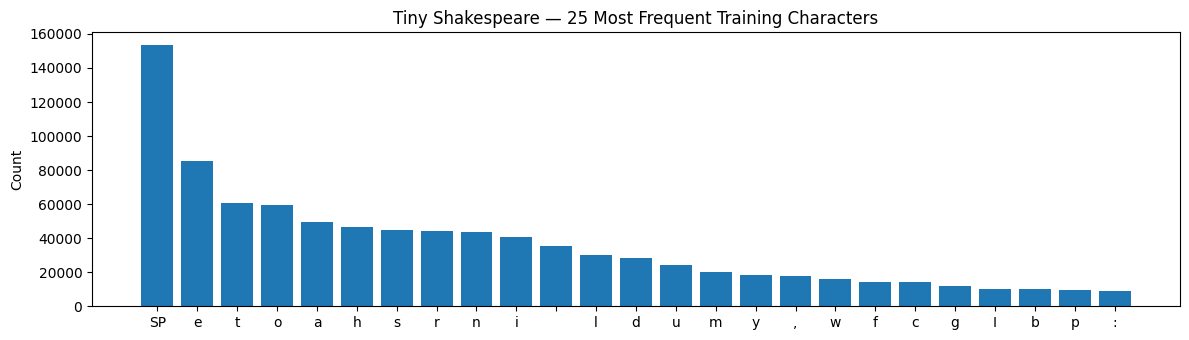

In [6]:
print("--- First 500 training characters ---")
print()
print(train_text[:500])

from collections import Counter
counts = Counter(train_text)
most_common = counts.most_common(25)
labels = [("\n" if ch == "\n" else "SP" if ch == " " else ch) for ch, _ in most_common]
values = [count for _, count in most_common]

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(range(len(values)), values)
ax.set_xticks(range(len(values)))
ax.set_xticklabels(labels)
ax.set_title("Tiny Shakespeare — 25 Most Frequent Training Characters")
ax.set_ylabel("Count")
fig.tight_layout()
plt.show()


## 7. Create full sequence datasets

No sequence sampling is performed. Contiguous non-overlapping chunks are used, and the final shorter chunk is padded. Padded target positions are ignored in the loss, so every available next-character pair is used exactly once per epoch.


In [7]:
class FullSequenceDataset(Dataset):
    def __init__(self, ids, seq_len):
        self.ids = ids
        self.seq_len = seq_len
        self.n_pairs = max(len(ids)-1, 0)
        self.n_sequences = math.ceil(self.n_pairs / seq_len)

    def __len__(self):
        return self.n_sequences

    def __getitem__(self, index):
        start = index * self.seq_len
        end = min(start + self.seq_len, self.n_pairs)
        x = self.ids[start:end]
        y = self.ids[start+1:end+1]
        valid = len(x)
        if valid < self.seq_len:
            x_pad = torch.zeros(self.seq_len, dtype=torch.long)
            y_pad = torch.full((self.seq_len,), IGNORE_INDEX, dtype=torch.long)
            x_pad[:valid] = x
            y_pad[:valid] = y
            x, y = x_pad, y_pad
        return x, y, valid

train_dataset = FullSequenceDataset(train_ids, SEQ_LEN)
val_dataset = FullSequenceDataset(val_ids, SEQ_LEN)
test_dataset = FullSequenceDataset(test_ids, SEQ_LEN)

def make_loaders(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator, drop_last=False, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=0, pin_memory=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=0, pin_memory=False)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(SEED)
print("Training next-character pairs:", f"{train_dataset.n_pairs:,}")
print("Validation next-character pairs:", f"{val_dataset.n_pairs:,}")
print("Test next-character pairs:", f"{test_dataset.n_pairs:,}")
print("Training batches/epoch:", len(train_loader))


Training next-character pairs: 1,003,853
Validation next-character pairs: 55,768
Test next-character pairs: 55,770
Training batches/epoch: 123


## 8. LSTM model

This is a character-level PyTorch LSTM. The model is initialized on CPU with the fixed seed and then moved to the selected device, so CPU and GPU begin from the same parameters.


In [8]:

class CharLSTM(nn.Module):
    def __init__(
        self,
        vocab_size=VOCAB_SIZE,
        embedding_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=(
                DROPOUT
                if num_layers > 1
                else 0.0
            ),
        )

        self.head = nn.Linear(
            hidden_dim,
            vocab_size,
        )

    def forward(
        self,
        x,
        hidden=None,
    ):
        embedded = self.embedding(
            x
        )

        output, hidden = self.lstm(
            embedded,
            hidden,
        )

        logits = self.head(
            output
        )

        return (
            logits,
            hidden,
        )


# Always initialize on CPU first.
set_seed(SEED)

model = CharLSTM()

INITIAL_STATE = copy.deepcopy(
    model.state_dict()
)

model = model.to(
    DEVICE
)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Trainable parameters:", f"{parameter_count:,}")
print("Model device:", next(model.parameters()).device)


Trainable parameters: 2,210,497
Model device: cuda:0


## 9. Verify identical initialization

In [9]:

# Rebuild the CPU reference state deterministically.
set_seed(SEED)

reference_model = CharLSTM()

reference_state = reference_model.state_dict()

for name, value in INITIAL_STATE.items():
    assert torch.equal(
        value,
        reference_state[
            name
        ],
    )

del reference_model

print("Initialization verified.")
print("DEVICE changes where the same parameters execute, not their starting values.")


Initialization verified.
DEVICE changes where the same parameters execute, not their starting values.


## 10. CodeCarbon, RAM, and GPU-memory helpers

In [10]:

process = psutil.Process(
    os.getpid()
)


def sync():
    if DEVICE == "cuda":
        torch.cuda.synchronize()


class PeakMemory:
    def __init__(
        self,
        interval=0.10,
    ):
        self.interval = interval
        self.peak_rss = 0
        self.stop_event = threading.Event()
        self.thread = None

    def _watch(self):
        while not self.stop_event.is_set():
            try:
                self.peak_rss = max(
                    self.peak_rss,
                    process.memory_info().rss,
                )
            except Exception:
                pass

            time.sleep(
                self.interval
            )

    def start(self):
        self.peak_rss = (
            process.memory_info().rss
        )

        self.stop_event.clear()

        self.thread = threading.Thread(
            target=self._watch,
            daemon=True,
        )

        self.thread.start()

    def stop(self):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join(
                timeout=2
            )

        return (
            self.peak_rss
            / (1024 ** 2)
        )


class EnergyTracker:
    def __init__(
        self,
        project_name,
    ):
        self.tracker = None

        try:
            kwargs = dict(
                project_name=project_name,
                measure_power_secs=CARBON_MEASURE_SECS,
                tracking_mode="process",

                # CPU benchmark must not include an attached idle GPU.
                # GPU benchmark explicitly tracks GPU 0.
                gpu_ids=[0] if DEVICE == "cuda" else [],

                log_level="error",
            )

            try:
                self.tracker = EmissionsTracker(
                    output_methods=[],
                    **kwargs,
                )

            except TypeError:
                self.tracker = EmissionsTracker(
                    save_to_file=False,
                    save_to_api=False,
                    **kwargs,
                )

        except Exception as exc:
            print(
                "CodeCarbon initialization unavailable:",
                exc,
            )

    def start(self):
        if self.tracker is not None:
            try:
                self.tracker.start()

            except Exception as exc:
                print(
                    "CodeCarbon start failed:",
                    exc,
                )

                self.tracker = None

    def stop(self):
        if self.tracker is None:
            return self.empty()

        try:
            self.tracker.stop()

            data = getattr(
                self.tracker,
                "final_emissions_data",
                None,
            )

            if data is None:
                return self.empty()

            def attr(name):
                value = getattr(
                    data,
                    name,
                    np.nan,
                )

                return (
                    np.nan
                    if value is None
                    else value
                )

            return {
                "energy_kwh":
                    attr("energy_consumed"),

                "co2_kg":
                    attr("emissions"),

                "cpu_energy_kwh":
                    attr("cpu_energy"),

                "gpu_energy_kwh":
                    attr("gpu_energy"),

                "ram_energy_kwh":
                    attr("ram_energy"),

                "cpu_power_w":
                    attr("cpu_power"),

                "gpu_power_w":
                    attr("gpu_power"),

                "country":
                    getattr(
                        data,
                        "country_name",
                        None,
                    ),
            }

        except Exception as exc:
            print(
                "CodeCarbon stop failed:",
                exc,
            )

            return self.empty()

    @staticmethod
    def empty():
        return {
            "energy_kwh": np.nan,
            "co2_kg": np.nan,
            "cpu_energy_kwh": np.nan,
            "gpu_energy_kwh": np.nan,
            "ram_energy_kwh": np.nan,
            "cpu_power_w": np.nan,
            "gpu_power_w": np.nan,
            "country": None,
        }


## 11. Warm-up

In [11]:

@torch.no_grad()
def warm_up():
    model.eval()

    x, _, _ = next(
        iter(
            train_loader
        )
    )

    x = x.to(
        DEVICE
    )

    _ = model(
        x
    )

    sync()


warm_up()

if DEVICE == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print("Warm-up complete outside measured training region.")


Warm-up complete outside measured training region.


## 12. Train the LSTM

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
training_tracker = EnergyTracker(f"tiny-shakespeare-LSTM-{DEVICE}-training")
training_memory = PeakMemory()
training_history_ce = []
training_epoch_times = []
training_tracker.start()
training_memory.start()
sync()
training_start = time.perf_counter()

for epoch in range(EPOCHS):
    model.train()
    epoch_start = time.perf_counter()
    total_loss = 0.0
    total_tokens = 0
    for x, y, valid_counts in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits, _ = model(x)
        loss_sum = F.cross_entropy(
            logits.reshape(-1, VOCAB_SIZE),
            y.reshape(-1),
            ignore_index=IGNORE_INDEX,
            reduction="sum",
        )
        valid_tokens = int(valid_counts.sum().item())
        loss = loss_sum / valid_tokens
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        total_loss += loss_sum.item()
        total_tokens += valid_tokens

    sync()
    epoch_time_s = time.perf_counter() - epoch_start
    epoch_ce = total_loss / total_tokens
    training_history_ce.append(epoch_ce)
    training_epoch_times.append(epoch_time_s)
    print(f"Epoch {epoch+1}/{EPOCHS} | CE={epoch_ce:.4f} | BPC={epoch_ce/LN2:.4f} | time={epoch_time_s:.2f}s")

sync()
training_time_s = time.perf_counter() - training_start
peak_process_ram_mb = training_memory.stop()
training_environmental = training_tracker.stop()
peak_gpu_mb = np.nan
if DEVICE == "cuda":
    peak_gpu_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

training_tokens = train_dataset.n_pairs * EPOCHS
training_throughput_tokens_s = training_tokens / training_time_s
print()
print(f"Training time: {training_time_s:.3f} s")
print(f"Training throughput: {training_throughput_tokens_s:,.1f} chars/s")
print(f"Peak process RAM: {peak_process_ram_mb:.2f} MB")
if DEVICE == "cuda":
    print(f"Peak GPU memory: {peak_gpu_mb:.2f} MB")
print("Training energy (kWh):", training_environmental["energy_kwh"])
print("Training CO2e (kg):", training_environmental["co2_kg"])


[codecarbon WARNING @ 06:05:24] Multiple instances of codecarbon are allowed to run at the same time.


Epoch 1/5 | CE=2.4979 | BPC=3.6037 | time=5.34s
Epoch 2/5 | CE=1.8163 | BPC=2.6203 | time=4.94s
Epoch 3/5 | CE=1.6203 | BPC=2.3377 | time=4.94s
Epoch 4/5 | CE=1.5259 | BPC=2.2014 | time=4.94s
Epoch 5/5 | CE=1.4661 | BPC=2.1152 | time=4.97s

Training time: 25.140 s
Training throughput: 199,655.6 chars/s
Peak process RAM: 1300.08 MB
Peak GPU memory: 346.46 MB
Training energy (kWh): 0.0005643068516830444
Training CO2e (kg): 0.000255417004627545


## 13. Validation evaluation

In [13]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    for x, y, valid_counts in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits, _ = model(x)
        loss_sum = F.cross_entropy(
            logits.reshape(-1, VOCAB_SIZE),
            y.reshape(-1),
            ignore_index=IGNORE_INDEX,
            reduction="sum",
        )
        total_loss += loss_sum.item()
        total_tokens += int(valid_counts.sum().item())
    ce = total_loss / total_tokens
    bpc = ce / LN2
    perplexity = math.exp(ce)
    return ce, bpc, perplexity, total_tokens

val_ce, val_bpc, val_perplexity, val_token_count = evaluate(val_loader)
print(f"Validation CE: {val_ce:.5f}")
print(f"Validation BPC: {val_bpc:.5f}")
print(f"Validation perplexity: {val_perplexity:.5f}")
print("Validation characters evaluated:", f"{val_token_count:,}")


Validation CE: 1.54608
Validation BPC: 2.23052
Validation perplexity: 4.69304
Validation characters evaluated: 55,768


## 14. Timed test-set inference

In [14]:
with torch.no_grad():
    test_x, _, _ = next(iter(test_loader))
    _ = model(test_x.to(DEVICE))

sync()
if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()

test_tracker = EnergyTracker(f"tiny-shakespeare-LSTM-{DEVICE}-test")
test_memory = PeakMemory()
test_tracker.start()
test_memory.start()
sync()
test_start = time.perf_counter()
test_ce, test_bpc, test_perplexity, test_token_count = evaluate(test_loader)
sync()
test_time_s = time.perf_counter() - test_start
test_peak_ram_mb = test_memory.stop()
test_environmental = test_tracker.stop()
test_peak_gpu_mb = np.nan
if DEVICE == "cuda":
    test_peak_gpu_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

test_throughput_tokens_s = test_token_count / test_time_s
test_latency_ms_per_token = test_time_s / test_token_count * 1000
print(f"Test CE: {test_ce:.5f}")
print(f"Test BPC: {test_bpc:.5f}")
print(f"Test perplexity: {test_perplexity:.5f}")
print(f"Test inference time: {test_time_s:.5f} s")
print(f"Test throughput: {test_throughput_tokens_s:,.1f} chars/s")
print(f"Latency: {test_latency_ms_per_token:.6f} ms/char")
print("Test energy (kWh):", test_environmental["energy_kwh"])
print("Test CO2e (kg):", test_environmental["co2_kg"])


Test CE: 1.64626
Test BPC: 2.37505
Test perplexity: 5.18754
Test inference time: 0.12369 s
Test throughput: 450,889.7 chars/s
Latency: 0.002218 ms/char
Test energy (kWh): 3.327748972840148e-06
Test CO2e (kg): 1.5062083195697604e-06



## 15. Fair autoregressive generation

The generation prompt is the same first 128 characters from the validation subset.

To make stochastic generation comparable across separately run CPU/GPU notebooks, the notebook creates a fixed vector of **uniform random numbers on CPU using the same seed** before generation.

At each generation step, that same random value is used to sample from the model's temperature-scaled next-byte distribution.

Thus CPU and GPU do not use different random-number streams.


In [15]:

GEN_PROMPT = (
    val_ids[
        :SEQ_LEN
    ]
    .clone()
    .long()
)


def make_generation_uniforms(
    seed,
):
    generator = torch.Generator(
        device="cpu"
    )

    generator.manual_seed(
        seed
    )

    return torch.rand(
        GEN_LEN,
        generator=generator,
        dtype=torch.float32,
    )


@torch.no_grad()
def generate_once(
    uniform_cpu,
):
    model.eval()

    sequence = (
        GEN_PROMPT
        .unsqueeze(0)
        .to(
            DEVICE
        )
    )

    uniforms = uniform_cpu.to(
        DEVICE
    )

    generated = (
        GEN_PROMPT
        .tolist()
    )

    for step in range(
        GEN_LEN
    ):
        context = sequence[
            :,
            -SEQ_LEN:
        ]

        logits, _ = model(
            context
        )

        next_logits = (
            logits[
                0,
                -1,
                :
            ]
            / GEN_TEMPERATURE
        )

        probabilities = torch.softmax(
            next_logits,
            dim=-1,
        )

        cumulative = torch.cumsum(
            probabilities,
            dim=-1,
        )

        u = uniforms[
            step
        ]

        next_id = torch.searchsorted(
            cumulative,
            u,
        ).clamp(
            max=VOCAB_SIZE - 1
        )

        sequence = torch.cat(
            [
                sequence,
                next_id.view(
                    1,
                    1,
                ),
            ],
            dim=1,
        )

        generated.append(
            int(
                next_id.item()
            )
        )

    return generated


## 16. Timed generation

In [16]:

# Warm-up generation step outside measurement.
with torch.no_grad():
    warm_context = (
        GEN_PROMPT
        .unsqueeze(0)
        .to(
            DEVICE
        )
    )

    _ = model(
        warm_context
    )

sync()


generation_times = []
generation_energies = []
generation_co2_values = []

generated_ids = None

for generation_repeat in range(
    GEN_REPEATS
):
    uniform_cpu = make_generation_uniforms(
        SEED
        + 10_000
        + generation_repeat
    )

    tracker = EnergyTracker(
        f"tiny-shakespeare-LSTM-{DEVICE}-generation-{generation_repeat}"
    )

    tracker.start()

    sync()

    start = time.perf_counter()

    current_generated = generate_once(
        uniform_cpu
    )

    sync()

    elapsed = (
        time.perf_counter()
        - start
    )

    env = tracker.stop()

    generation_times.append(
        elapsed
    )

    generation_energies.append(
        env[
            "energy_kwh"
        ]
    )

    generation_co2_values.append(
        env[
            "co2_kg"
        ]
    )

    if generated_ids is None:
        generated_ids = current_generated


generation_time_s = float(
    np.mean(
        generation_times
    )
)

generation_time_std_s = float(
    np.std(
        generation_times,
        ddof=1,
    )
    if len(
        generation_times
    ) > 1
    else 0.0
)

generation_energy_kwh = float(
    np.nanmean(
        generation_energies
    )
)

generation_co2_kg = float(
    np.nanmean(
        generation_co2_values
    )
)

generation_throughput_chars_s = (
    GEN_LEN
    / generation_time_s
)


print(f"Mean generation time: {generation_time_s:.4f} s")
print(f"Generation time SD: {generation_time_std_s:.4f} s")
print(f"Generation throughput: {generation_throughput_chars_s:.2f} chars/s")
print(f"Mean generation energy: {generation_energy_kwh:.8f} kWh")
print(f"Mean generation CO2e: {generation_co2_kg:.8f} kg")


Mean generation time: 1.9330 s
Generation time SD: 0.0177 s
Generation throughput: 258.67 chars/s
Mean generation energy: 0.00004251 kWh
Mean generation CO2e: 0.00001924 kg


## 17. Generated sample

In [17]:

prompt_text = decode(
    generated_ids[
        :len(GEN_PROMPT)
    ]
)

generated_text = decode(
    generated_ids[
        len(GEN_PROMPT):
    ]
)

print("--- Prompt ---")
print(prompt_text)

print()
print("--- Generated continuation ---")
print(generated_text)


--- Prompt ---
?

GREMIO:
Good morrow, neighbour Baptista.

BAPTISTA:
Good morrow, neighbour Gremio.
God save you, gentlemen!

PETRUCHIO:
And y

--- Generated continuation ---
our depart as thy know, be gone to lords.

PORIXE:
I thought not I sent the better with strands, many bound
Can life of your courtery she tord and so bewold:
Let we devil not refore a love, sir, the trust; and a voice in the gold
To do the Devise upon thee son of the part is lost
Reneminess the early tibelies.

ROMEO:
And, the wife Marcius too fair, in these faces,
How shall have deserved and hands a mander, bethink hither
Will offence the starry store to be wabst for the bawd
That iss thy trupt


## 18. Training curve

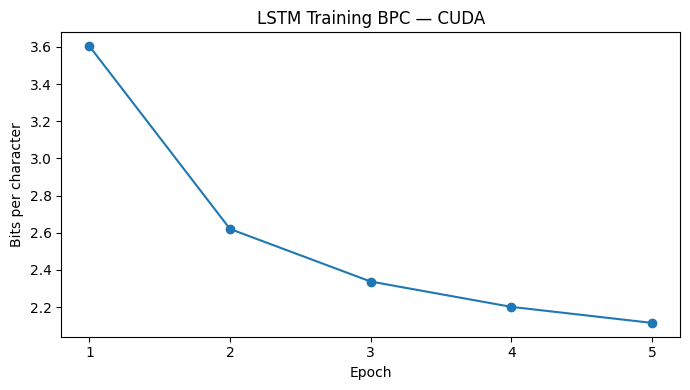

In [18]:

fig, ax = plt.subplots(
    figsize=(7, 4)
)

epochs = np.arange(
    1,
    EPOCHS + 1,
)

training_bpc = [
    ce / LN2
    for ce in training_history_ce
]

ax.plot(
    epochs,
    training_bpc,
    marker="o",
)

ax.set_title(
    f"LSTM Training BPC — {DEVICE.upper()}"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Bits per character"
)

ax.set_xticks(
    epochs
)

fig.tight_layout()

plt.show()


## 19. Final result table

In [19]:

result = {
    "task":
        "Text generation",

    "algorithm":
        "LSTM",

    "library":
        "PyTorch",

    "device":
        DEVICE,

    "seed":
        SEED,

    "dataset":
        "Tiny Shakespeare",

    "total_characters":
        len(text),

    "train_characters":
        len(train_ids),

    "validation_characters":
        len(val_ids),

    "test_characters":
        len(test_ids),

    "vocab_size":
        VOCAB_SIZE,

    "sequence_length":
        SEQ_LEN,

    "batch_size":
        BATCH_SIZE,

    "epochs":
        EPOCHS,

    "learning_rate":
        LEARNING_RATE,

    "embedding_dim":
        EMBED_DIM,

    "hidden_dim":
        HIDDEN_DIM,

    "num_layers":
        NUM_LAYERS,

    "trainable_parameters":
        parameter_count,

    "training_time_s":
        training_time_s,

    "mean_epoch_time_s":
        float(
            np.mean(
                training_epoch_times
            )
        ),

    "training_throughput_chars_s":
        training_throughput_tokens_s,

    "validation_bpc":
        val_bpc,

    "validation_perplexity":
        val_perplexity,

    "test_bpc":
        test_bpc,

    "test_perplexity":
        test_perplexity,

    "test_inference_time_s":
        test_time_s,

    "test_throughput_chars_s":
        test_throughput_tokens_s,

    "test_latency_ms_per_char":
        test_latency_ms_per_token,

    "generation_length":
        GEN_LEN,

    "generation_time_s":
        generation_time_s,

    "generation_time_std_s":
        generation_time_std_s,

    "generation_throughput_chars_s":
        generation_throughput_chars_s,

    "peak_process_ram_mb":
        peak_process_ram_mb,

    "peak_gpu_mb":
        peak_gpu_mb,

    "training_energy_kwh":
        training_environmental[
            "energy_kwh"
        ],

    "training_co2_kg":
        training_environmental[
            "co2_kg"
        ],

    "training_co2_g":
        (
            training_environmental[
                "co2_kg"
            ]
            * 1000
            if pd.notna(
                training_environmental[
                    "co2_kg"
                ]
            )
            else np.nan
        ),

    "training_cpu_energy_kwh":
        training_environmental[
            "cpu_energy_kwh"
        ],

    "training_gpu_energy_kwh":
        training_environmental[
            "gpu_energy_kwh"
        ],

    "training_ram_energy_kwh":
        training_environmental[
            "ram_energy_kwh"
        ],

    "test_energy_kwh":
        test_environmental[
            "energy_kwh"
        ],

    "test_co2_kg":
        test_environmental[
            "co2_kg"
        ],

    "generation_energy_kwh":
        generation_energy_kwh,

    "generation_co2_kg":
        generation_co2_kg,

    "carbon_country":
        training_environmental[
            "country"
        ],
}

result_df = pd.DataFrame(
    [result]
)

display(
    result_df.round(6)
)


,task,algorithm,library,device,seed,dataset,total_characters,train_characters,validation_characters,test_characters,vocab_size,sequence_length,batch_size,epochs,learning_rate,embedding_dim,hidden_dim,num_layers,trainable_parameters,training_time_s,mean_epoch_time_s,training_throughput_chars_s,validation_bpc,validation_perplexity,test_bpc,test_perplexity,test_inference_time_s,test_throughput_chars_s,test_latency_ms_per_char,generation_length,generation_time_s,generation_time_std_s,generation_throughput_chars_s,peak_process_ram_mb,peak_gpu_mb,training_energy_kwh,training_co2_kg,training_co2_g,training_cpu_energy_kwh,training_gpu_energy_kwh,training_ram_energy_kwh,test_energy_kwh,test_co2_kg,generation_energy_kwh,generation_co2_kg,carbon_country
0,Text generation,LSTM,PyTorch,cuda,42,Tiny Shakespeare,1115394,1003854,55769,55771,65,128,64,5,0.001,256,384,2,2210497,25.139619,5.027601,199655.574679,2.230523,4.69304,2.375051,5.187543,0.123689,450889.666676,0.002218,500,1.932972,0.017729,258.669036,1300.082031,346.458984,0.000564,0.000255,0.255417,0.000028,0.000467,0.000069,0.000003,0.000002,0.000043,0.000019,United States


## 20. Save this device's result

In [20]:

output_dir = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path(".")
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

result_path = (
    output_dir
    / f"lstm_tiny_shakespeare_{DEVICE}_result.csv"
)

sample_path = (
    output_dir
    / f"lstm_tiny_shakespeare_{DEVICE}_generated.txt"
)

result_df.to_csv(
    result_path,
    index=False,
)

sample_path.write_text(
    generated_text,
    encoding="utf-8",
)

print("Saved result:", result_path)
print("Saved generated text:", sample_path)


Saved result: /kaggle/working/lstm_tiny_shakespeare_cuda_result.csv
Saved generated text: /kaggle/working/lstm_tiny_shakespeare_cuda_generated.txt



## 21. Optional CPU-vs-GPU comparison

If both:

```text
lstm_tiny_shakespeare_cpu_result.csv
lstm_tiny_shakespeare_cuda_result.csv
```

exist in the same working directory, this cell calculates the paired comparison automatically.


In [21]:

cpu_path = (
    output_dir
    / "lstm_tiny_shakespeare_cpu_result.csv"
)

gpu_path = (
    output_dir
    / "lstm_tiny_shakespeare_cuda_result.csv"
)


if (
    cpu_path.exists()
    and gpu_path.exists()
):

    cpu = pd.read_csv(
        cpu_path
    ).iloc[0]

    gpu = pd.read_csv(
        gpu_path
    ).iloc[0]


    training_speedup = (
        cpu[
            "training_time_s"
        ]
        /
        gpu[
            "training_time_s"
        ]
    )


    inference_speedup = (
        cpu[
            "test_inference_time_s"
        ]
        /
        gpu[
            "test_inference_time_s"
        ]
    )


    generation_speedup = (
        cpu[
            "generation_time_s"
        ]
        /
        gpu[
            "generation_time_s"
        ]
    )


    energy_saving_pct = (
        (
            cpu[
                "training_energy_kwh"
            ]
            -
            gpu[
                "training_energy_kwh"
            ]
        )
        /
        cpu[
            "training_energy_kwh"
        ]
        * 100
        if cpu[
            "training_energy_kwh"
        ] > 0
        else np.nan
    )


    carbon_saving_pct = (
        (
            cpu[
                "training_co2_kg"
            ]
            -
            gpu[
                "training_co2_kg"
            ]
        )
        /
        cpu[
            "training_co2_kg"
        ]
        * 100
        if cpu[
            "training_co2_kg"
        ] > 0
        else np.nan
    )


    comparison = pd.DataFrame([
        {
            "metric":
                "Training time (s)",

            "CPU":
                cpu[
                    "training_time_s"
                ],

            "GPU":
                gpu[
                    "training_time_s"
                ],
        },

        {
            "metric":
                "Test inference time (s)",

            "CPU":
                cpu[
                    "test_inference_time_s"
                ],

            "GPU":
                gpu[
                    "test_inference_time_s"
                ],
        },

        {
            "metric":
                "Generation time (s)",

            "CPU":
                cpu[
                    "generation_time_s"
                ],

            "GPU":
                gpu[
                    "generation_time_s"
                ],
        },

        {
            "metric":
                "Training energy (kWh)",

            "CPU":
                cpu[
                    "training_energy_kwh"
                ],

            "GPU":
                gpu[
                    "training_energy_kwh"
                ],
        },

        {
            "metric":
                "Training CO2e (g)",

            "CPU":
                cpu[
                    "training_co2_g"
                ],

            "GPU":
                gpu[
                    "training_co2_g"
                ],
        },

        {
            "metric":
                "Test BPC",

            "CPU":
                cpu[
                    "test_bpc"
                ],

            "GPU":
                gpu[
                    "test_bpc"
                ],
        },

        {
            "metric":
                "Test perplexity",

            "CPU":
                cpu[
                    "test_perplexity"
                ],

            "GPU":
                gpu[
                    "test_perplexity"
                ],
        },
    ])


    display(
        comparison.round(6)
    )


    print(
        f"GPU training speedup = {training_speedup:.3f}x"
    )

    print(
        f"GPU inference speedup = {inference_speedup:.3f}x"
    )

    print(
        f"GPU generation speedup = {generation_speedup:.3f}x"
    )

    print(
        f"GPU training energy saving = {energy_saving_pct:.2f}%"
    )

    print(
        f"GPU training carbon saving = {carbon_saving_pct:.2f}%"
    )

    print(
        f"GPU - CPU test BPC = "
        f"{gpu['test_bpc'] - cpu['test_bpc']:.6f}"
    )

else:
    print(
        "Both CPU and GPU result files are not present yet."
    )

    print(
        "Run this notebook once with DEVICE='cpu' "
        "and once with DEVICE='cuda'."
    )


Both CPU and GPU result files are not present yet.
Run this notebook once with DEVICE='cpu' and once with DEVICE='cuda'.


# How to use this notebook

Run once with `DEVICE = "cpu"`, then change only that line to `DEVICE = "cuda"` and rerun.

The notebook uses the **full Tiny Shakespeare text with no sampling**, a deterministic 90/5/5 split, the same vocabulary and model settings, and the same fixed initialization/batch order for the CPU/GPU pair.

Saved files:
```text
lstm_tiny_shakespeare_cpu_result.csv
lstm_tiny_shakespeare_cuda_result.csv
```
